In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
from brainspace.gradient import GradientMaps
from utils import get_basic_mask
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder_orig = '/mnt_03/ds-dnumrisk' 

plot_folder = op.join(bids_folder_orig, 'plots_and_ims/gradient_stuff')
phenotype_folder = op.join(bids_folder_orig, 'derivatives/phenotype')

from os import listdir
subList = [f[4:6] for f in listdir(op.join(bids_folder_orig)) if f[0:4] == 'sub-' and len(f)==6]

fsaverage = fetch_surf_fsaverage('fsaverage5') 

# add group info
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()



In [2]:
# get masks
surf_mask_L = op.join(bids_folder_orig, 'derivatives/surface_masks', 'desc-NPC_L_space-fsaverage5_hemi-lh.label.gii')
surf_mask_L = nib.load(surf_mask_L).agg_data()
surf_mask_R = op.join(bids_folder_orig, 'derivatives/surface_masks', 'desc-NPC_R_space-fsaverage5_hemi-rh.label.gii')
surf_mask_R = nib.load(surf_mask_R).agg_data()
nprf_r2 = np.concatenate((surf_mask_L, surf_mask_R))

mask, labeling_noParcel = get_basic_mask()
nprf_r2 = np.bool_(nprf_r2)

np.shape(nprf_r2)


[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


(20484,)

In [4]:
confspec='32P'
frames_per_run_thresh=104
scrub_thresh=0.3

confspec += f'scrub{str(scrub_thresh)[2]}'  #if scrubbing else confspec
confspec += 'BPfilter' #if bp_filtering else confspec
confspec += f'runFD{str(frames_per_run_thresh)}' #if run_FD_filter else confspec


In [6]:
## load in gradients

n_gradients = 5
gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm = op.join(bids_folder, 'derivatives', f'gradients.{confspec}', f'sub-{sub}')
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy'))
    for i in range(n_gradients):
        gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])

sub_array = np.array([int(i) for i in subList])
dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms_aligned[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    gradient_df = gradient_df.join(group_list).set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')

In [7]:
# take NPC as a network and compute dispersion
n_grad = 2
g1 = np.array(gms_aligned[f'g{n_grad}']).T # n_vertices x n_subjects

# get the gradient loadings of the nodes of the ROI, for each subject (shape: number of nodes in network x N)
G1_net = g1[nprf_r2]

centroid_cog_net = np.nanmedian(G1_net, axis=0)  #np.median(G1_net, axis=0)  
dist_nodes_to_centroid = G1_net - centroid_cog_net  # shape: number of nodes in network x N

NPC_dispersion = np.nanmean((dist_nodes_to_centroid**2), axis = 0) 

df = pd.DataFrame(np.array([NPC_dispersion, centroid_cog_net]).T, index=sub_array, columns=['NPC_dispersion', 'NPC_centroid'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)
# df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}.csv'))
df.head()


,,NPC_dispersion,NPC_centroid
subject,group,,
21,0,6.767973,-0.218371
59,0,1.868535,-0.365539
54,0,10.761662,-0.043048
15,0,6.038725,0.332065
52,0,2.839846,0.135060


In [11]:
np.where(df['NPC_dispersion'] == df['NPC_dispersion'].max())

(array([10]),)

In [12]:
max_index = df['NPC_dispersion'].idxmax()

# Drop the row with the maximum 'NPC_dispersion'
df = df.drop(index=max_index)

TtestResult(statistic=-1.1375156800117818, pvalue=0.2638286921390985, df=31.772313188762816)


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 75.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 71.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


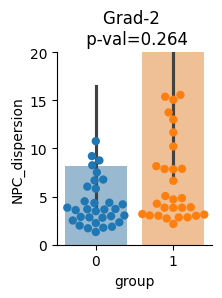

In [18]:
from scipy.stats import ttest_ind

y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion' # #  'NPC_centroid' # 

tmp = df.copy()

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
stats = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
p_val = np.round(stats.pvalue,3)
print(stats)

axes.set(title=f'Grad-{n_grad} \n p-val={p_val}',ylabel=y_var, xlabel='group',ylim=[0,30])
sns.despine()
